In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('50_Startups.csv')
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [4]:
dataset.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [6]:
x=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values
print(x.shape,y.shape)

(50, 4) (50,)


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[3])],remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [9]:
print(x.shape)

(50, 6)


In [10]:
x

array([[0.0, 0.0, 1.0, 165349.2, 136897.8, 471784.1],
       [1.0, 0.0, 0.0, 162597.7, 151377.59, 443898.53],
       [0.0, 1.0, 0.0, 153441.51, 101145.55, 407934.54],
       [0.0, 0.0, 1.0, 144372.41, 118671.85, 383199.62],
       [0.0, 1.0, 0.0, 142107.34, 91391.77, 366168.42],
       [0.0, 0.0, 1.0, 131876.9, 99814.71, 362861.36],
       [1.0, 0.0, 0.0, 134615.46, 147198.87, 127716.82],
       [0.0, 1.0, 0.0, 130298.13, 145530.06, 323876.68],
       [0.0, 0.0, 1.0, 120542.52, 148718.95, 311613.29],
       [1.0, 0.0, 0.0, 123334.88, 108679.17, 304981.62],
       [0.0, 1.0, 0.0, 101913.08, 110594.11, 229160.95],
       [1.0, 0.0, 0.0, 100671.96, 91790.61, 249744.55],
       [0.0, 1.0, 0.0, 93863.75, 127320.38, 249839.44],
       [1.0, 0.0, 0.0, 91992.39, 135495.07, 252664.93],
       [0.0, 1.0, 0.0, 119943.24, 156547.42, 256512.92],
       [0.0, 0.0, 1.0, 114523.61, 122616.84, 261776.23],
       [1.0, 0.0, 0.0, 78013.11, 121597.55, 264346.06],
       [0.0, 0.0, 1.0, 94657.16, 145077.58

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [12]:
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(40, 6) (10, 6)
(40,) (10,)


In [13]:
from sklearn.linear_model import LinearRegression
regressor  = LinearRegression()
regressor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = regressor.predict(x_test)
print(y_pred)

[103015.20159797 132582.27760816 132447.73845175  71976.09851257
 178537.48221056 116161.24230164  67851.69209675  98791.73374688
 113969.43533012 167921.06569552]


In [15]:
print(regressor.predict([[1,0,0,160000,130000,300000]]))

[181566.92389386]


In [16]:
print(regressor.coef_)
print(regressor.intercept_)

[ 8.66383692e+01 -8.72645791e+02  7.86007422e+02  7.73467193e-01
  3.28845975e-02  3.66100259e-02]
42467.52924855513


In [17]:
print('score:{}'.format(regressor.score(x_test,y_test)))

score:0.9347068473282829


In [19]:
plt.style.use('fivethirtyeight')

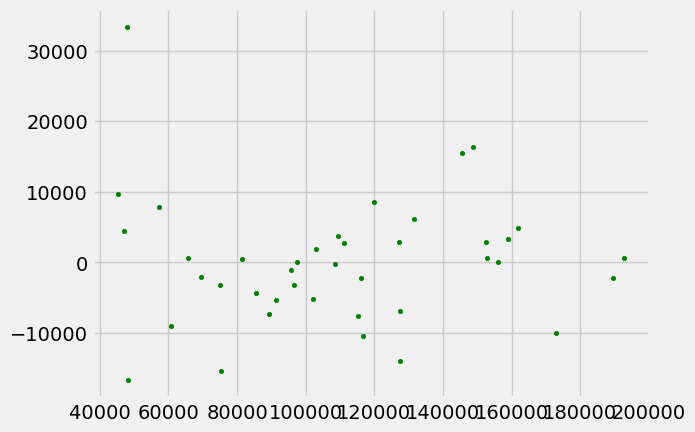

In [20]:
plt.scatter(regressor.predict(x_train),regressor.predict(x_train)-y_train,color='green',s=10,label='Train data')

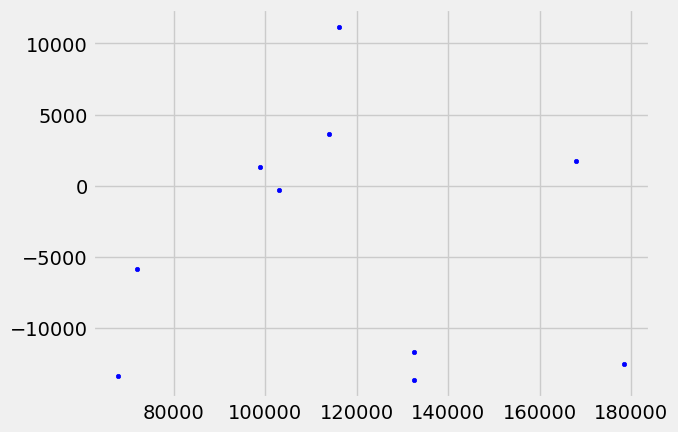

In [21]:
plt.scatter(regressor.predict(x_test),regressor.predict(x_test)-y_test,color='blue',s=10,label='test data')

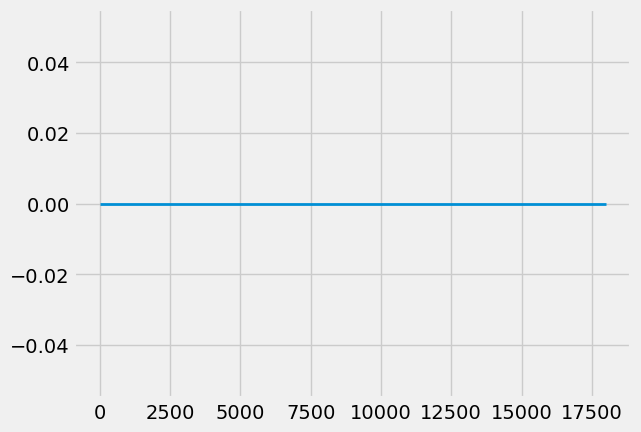

In [22]:
plt.hlines(y=0,xmin=0,xmax=18000,linewidth=2)

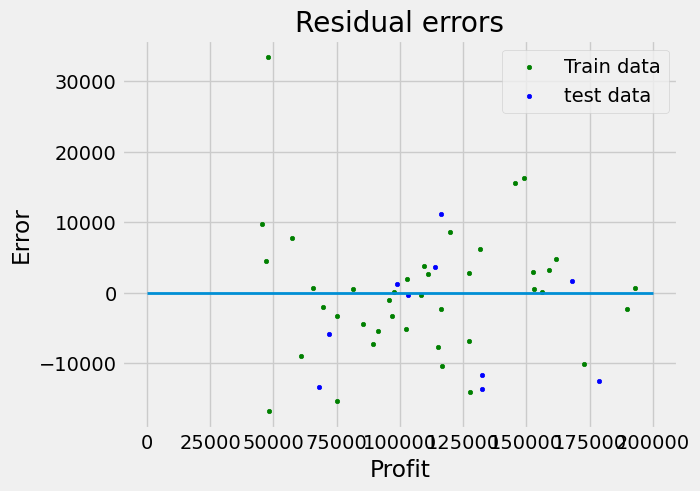

In [24]:
plt.style.use('fivethirtyeight')
plt.scatter(regressor.predict(x_train),regressor.predict(x_train)-y_train,color='green',s=10,label='Train data')
plt.scatter(regressor.predict(x_test),regressor.predict(x_test)-y_test,color='blue',s=10,label='test data')
plt.hlines(y=0,xmin=0,xmax=200000,linewidth=2)
plt.legend(loc='upper right')
plt.title("Residual errors")
plt.xlabel("Profit")
plt.ylabel("Error")
plt.show()

In [25]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.9347068473282829


In [ ]:
# MAE , RMSE